In [ ]:
"""
Model Parameters
Model parameters are the variables that are learned automatically by the model during training. 
The model adjusts these values to minimize error and improve predictions.
Example: Linear Regression  Equation: y = mx + c
Where:m = Slope (Weight) ,c = Intercept (Bias)
Here: Model Parameters: m and c

Hyperparameters are explicitly defined by the user to control the learning process.
✅ Their best values can be found using:
    Rule of Thumb
    Trial and Error
    Hyperparameter Tuning Techniques

Example: Decision Tree Classifier
DecisionTreeClassifier( criterion='entropy', max_depth=None, class_weight=None)
Here: criterion, max_depth, class_weight are Hyperparameters.

Other common hyperparameters: min_samples_split, min_samples_leaf, max_features, splitter
| Model Parameters            | Hyperparameters                      |
| --------------------------- | ------------------------------------ |
| Learned by model            | Set by user                          |
| Change during training      | Fixed before training                |
| Example: m, c               | Example: max_depth, k, learning_rate |
| Directly affect predictions | Control learning process             |
"""

In [ ]:
# Hyperparameter Tuning
"""
Hyperparameter tuning is the process of finding the best combination of hyperparameters 
to maximize model performance.
Hyperparameter Tuning Techniques

1. Grid Search
Grid Search tries all possible combinations of the given hyperparameter values.
Example Suppose:
Parameter A = {1,2,3}
Parameter B = {10,20,30}
Grid Search checks every combination.

Diagram
                 Parameter B
               10     20     30
            ----------------------
A = 1      |  82% | 85% | 80% |
            ----------------------
A = 2      |  86% | 91% | 88% |
            ----------------------
A = 3      |  84% | 89% | 87% |
            ----------------------

Best Accuracy = 91%

Best Parameters:
A = 2
B = 20

Working
Given Hyperparameters
          │
          ▼
Generate All Combinations
          │
          ▼
Train Model on Each Combination
          │
          ▼
Compare Accuracy
          │
          ▼
Select Best Combination
"""

In [ ]:
"""
2. Randomized Search CV
Randomized Search does not check every combination.
Instead, it randomly selects a fixed number of combinations from the search space.
"Randomized Search randomly samples a fixed number of hyperparameter combinations from the search space and evaluates only those combinations."

Diagram
Possible Combinations

(1,10)
(1,20)
(1,30)

(2,10)
(2,20)
(2,30)

(3,10)
(3,20)
(3,30)


Randomly Selected:

✓ (1,20)
✓ (2,30)
✓ (3,10)
✓ (2,20)

Only These Are Evaluated


Randomized Search Workflow
Hyperparameter Space
          │
          ▼
Randomly Pick N Combinations
          │
          ▼
Train Models
          │
          ▼
Compare Scores
          │
          ▼
Best Combination Selected
"""

In [ ]:
"""
| Grid Search                  | Randomized Search                      |
| ---------------------------- | -------------------------------------- |
| Checks all combinations      | Checks random combinations             |
| Slower                       | Faster                                 |
| More computational cost      | Less computational cost                |
| Good for small search spaces | Good for large search spaces           |
| May find best combination    | Finds near-optimal combination quickly |
"""

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np 

In [2]:
dataset = pd.read_csv("multiple_linear_regression_dataset.csv")
dataset.head(3)

,age,income,experience
0,25,30450,1
1,30,35670,3
2,47,31580,2


In [3]:
dataset.isnull().sum()

age           0
income        0
experience    0
dtype: int64

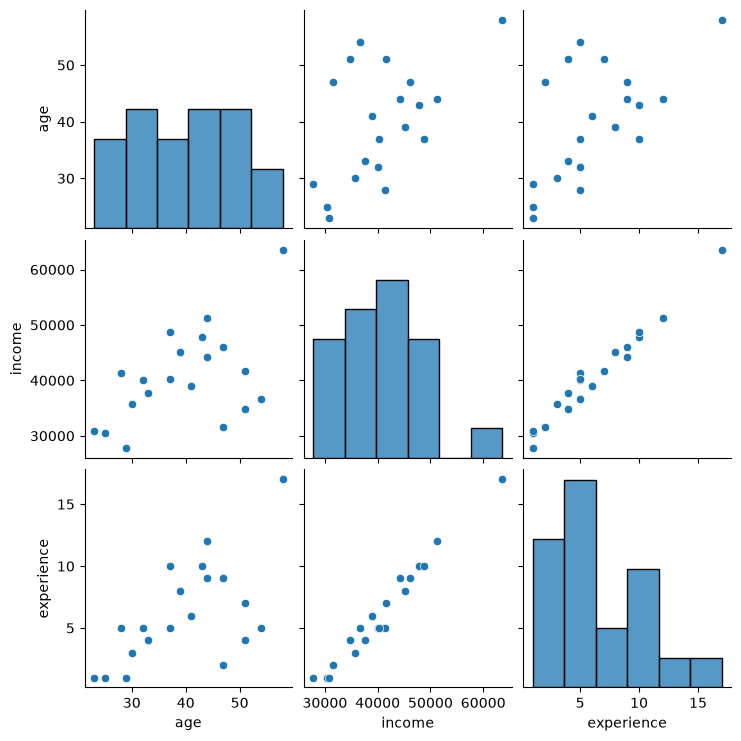

In [4]:
sns.pairplot(data=dataset)
plt.show()
x = dataset.iloc[:,:-1]
y = dataset["experience"]
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x,y , test_size=0.2 , random_state=42)

In [5]:
from sklearn.tree import DecisionTreeRegressor , plot_tree
dt = DecisionTreeRegressor( )
# """
# criterion: {"squared_error", "friedman_mse", "absolute_error", "poisson"}, default="squared_error" The function 
# to measure the quality of a split. Supported criteria are "squared_error" for the mean squared error, which is equal 
# to variance reduction as feature selection criterion and minimizes the L2 loss using the mean of each terminal node, 
# "friedman_mse", which uses mean squared error with Friedman's improvement score for potential splits, "absolute_error" 
# for the mean absolute error, which minimizes the L1 loss using the median of each terminal node, and "poisson" which uses 
# reduction in the half mean Poisson deviance to find splits.
# """
dt.fit(x_train,y_train)
dt.score(x_test,y_test)*100 , dt.score(x_train,y_train)*100 , dt.score(x_test,y_test)*100-dt.score(x_train,y_train)*100

(88.05970149253731, 100.0, -11.940298507462686)

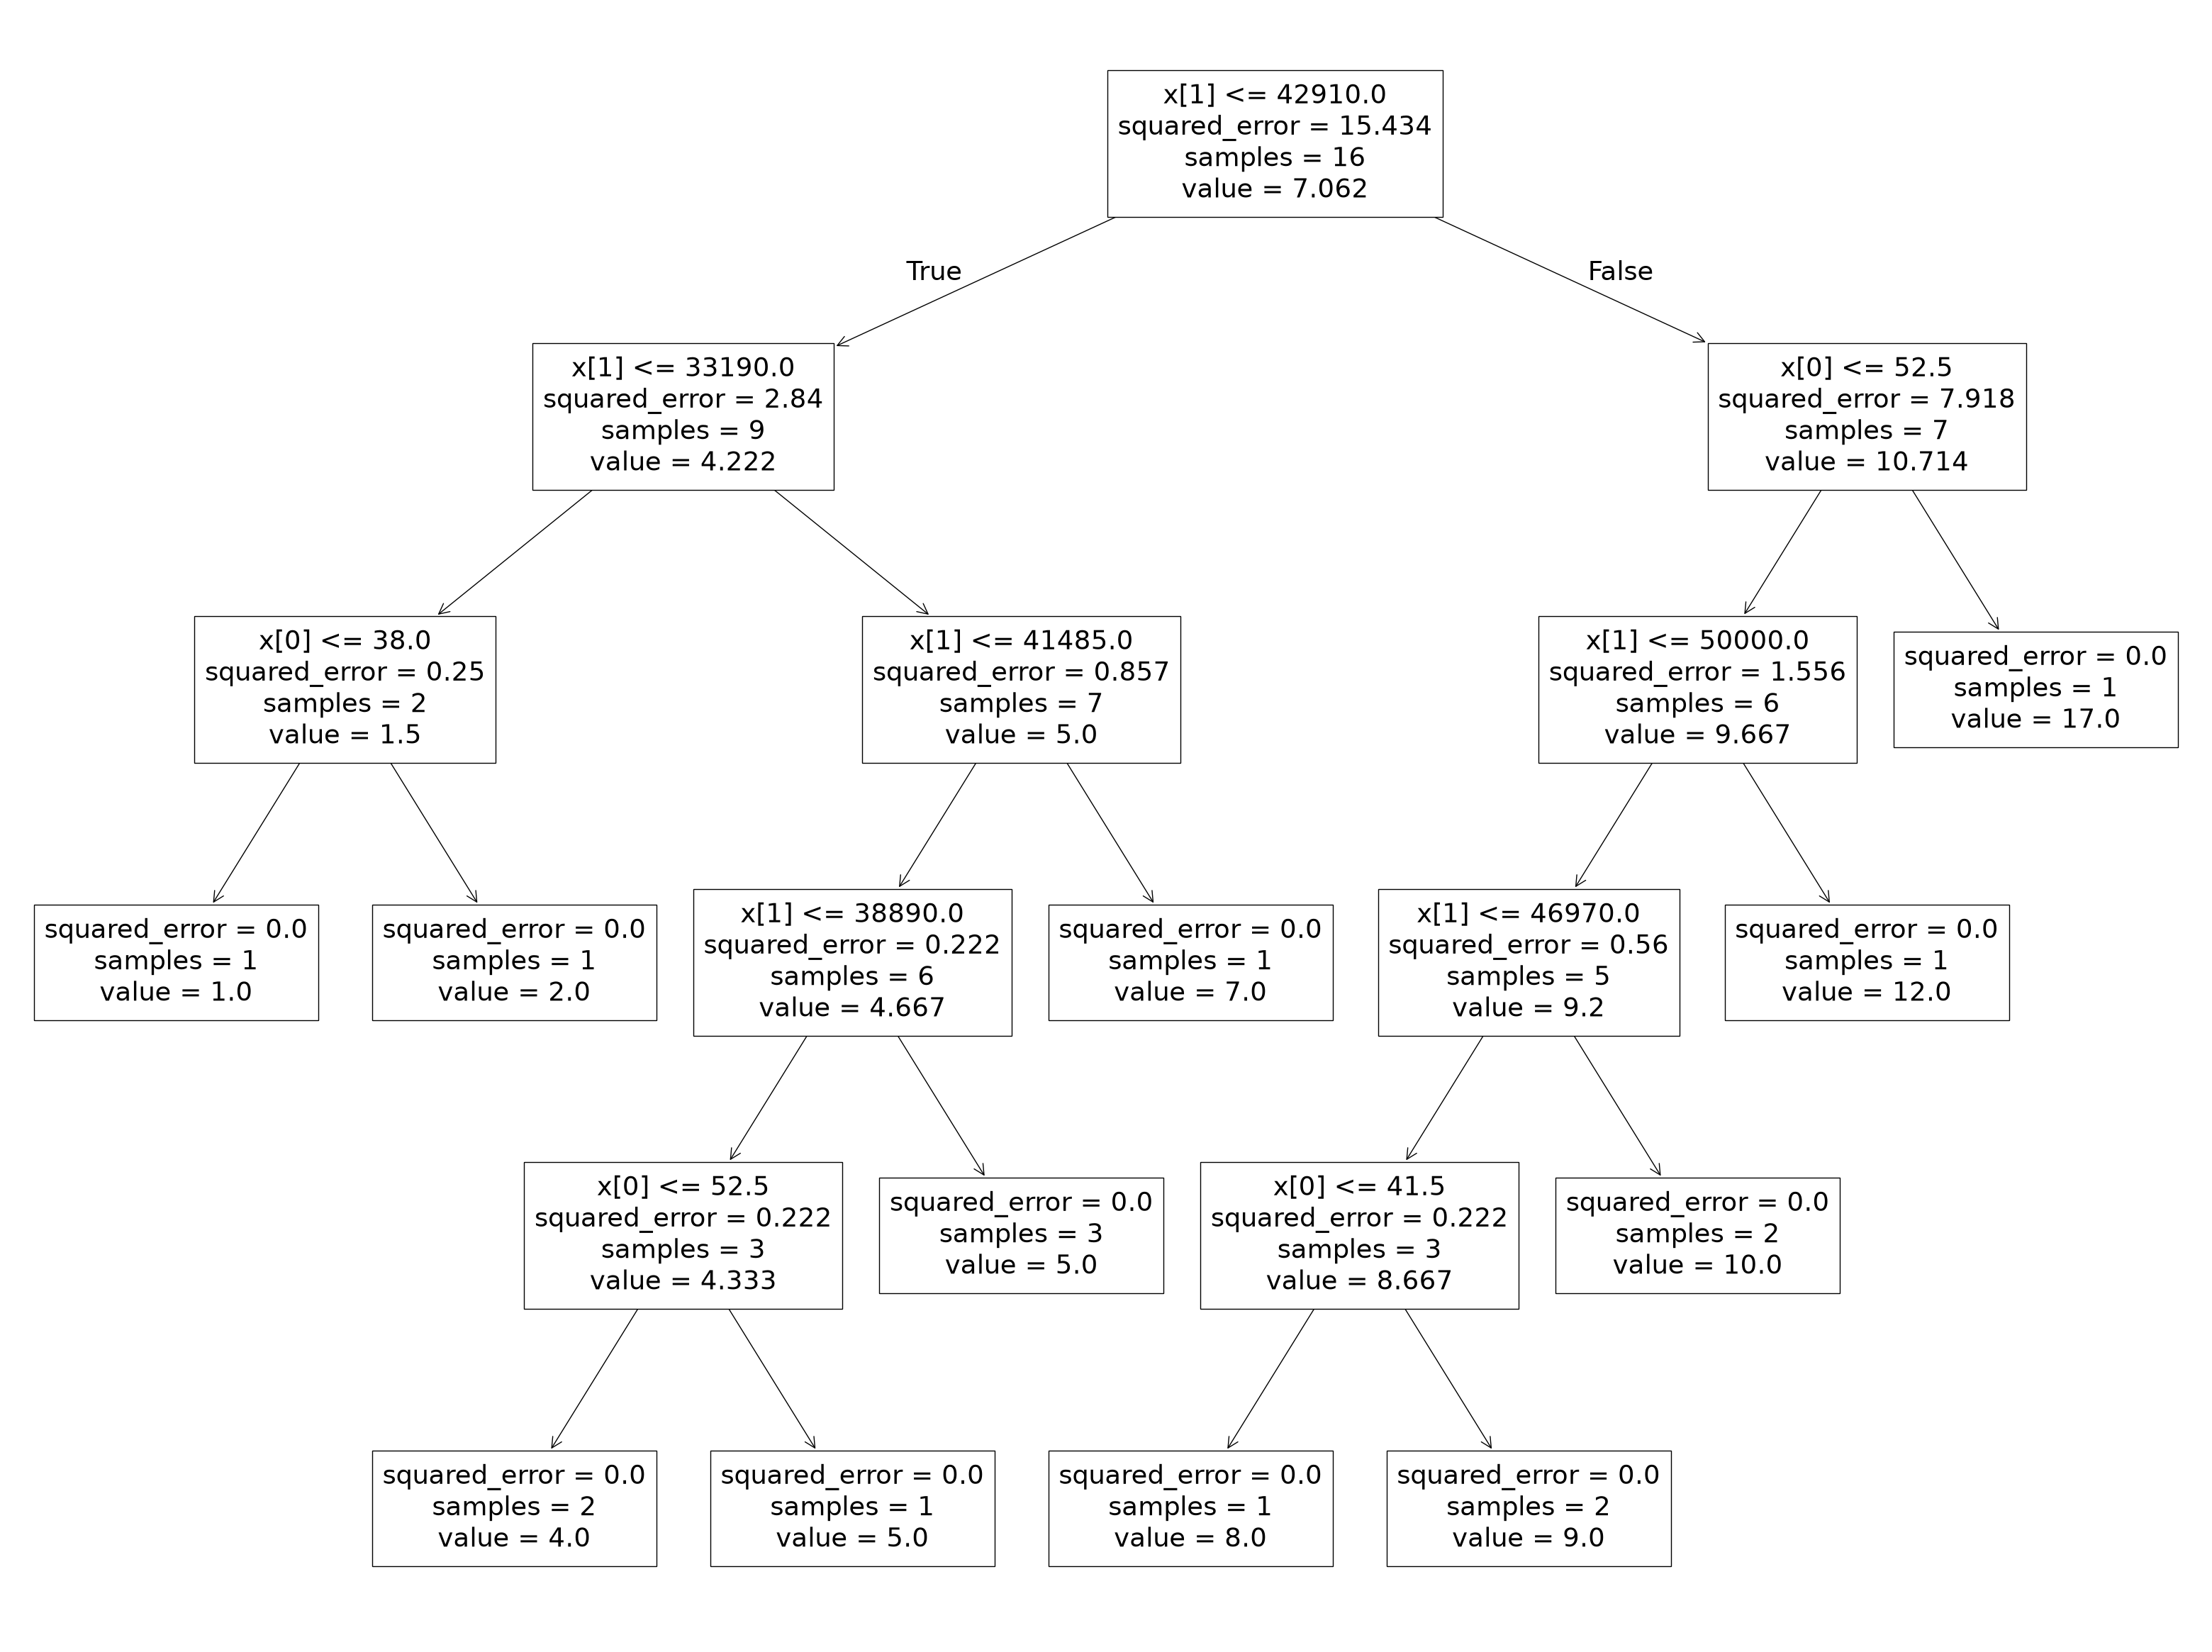

In [6]:
plt.figure(figsize=(40,30))
plot_tree(dt)
plt.show()

In [9]:
from sklearn.model_selection import GridSearchCV , RandomizedSearchCV
param_grid = {
    "criterion": ["squared_error", "friedman_mse", "absolute_error", "poisson"],
    "splitter": ["best", "random"],
    "max_depth": [2, 4, 6, 8, 10, 20, 30, None],
    "min_samples_split": [2, 5, 10, 15, 20]
}
gd= GridSearchCV(DecisionTreeRegressor( ),param_grid=param_grid)
gd.fit(x_train,y_train)


C:\Users\Pushpendra\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_validation.py:489: FitFailedWarning: 
400 fits failed out of a total of 1600.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
400 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Pushpendra\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Pushpendra\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py", line 1393, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\Users\Pushpendra

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['squared_error', 'friedman_mse', ...], 'max_depth': [2, 4, ...], 'min_samples_split': [2, 5, ...], 'splitter': ['best', 'random']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-

In [11]:
gd.best_params_

{'criterion': 'squared_error',
 'max_depth': 30,
 'min_samples_split': 2,
 'splitter': 'best'}

In [12]:
gd.best_score_

np.float64(0.7895743603733101)

In [13]:
rd = RandomizedSearchCV(DecisionTreeRegressor( ),param_distributions=param_grid)
rd.fit(x_train,y_train)

C:\Users\Pushpendra\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_validation.py:489: FitFailedWarning: 
5 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Pushpendra\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Pushpendra\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py", line 1393, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\Users\Pushpendra\AppDa

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeRegressor()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'criterion': ['squared_error', 'friedman_mse', ...], 'max_depth': [2, 4, ...], 'min_samples_split': [2, 5, ...], 'splitter': ['best', 'random']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the

In [14]:
rd.best_params_

{'splitter': 'random',
 'min_samples_split': 10,
 'max_depth': 20,
 'criterion': 'poisson'}

In [15]:
rd.best_score_

np.float64(0.44071374258677337)